#### **Player-Level EDA**

Goal: inspect player data health, club-strength distributions, squad aggregation, match differentials, and institutional benchmarks. 

This notebook supports the player-informed feature design used in the final model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

POS_COLORS = {"FW": "#D85A30", "MF": "#3266ad", "DF": "#1D9E75", "GK": "#BA7517"}


def repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find repo root with README.md and data/.")


def safe_rate(numer: pd.Series, denom: pd.Series) -> pd.Series:
    denom = denom.replace(0, np.nan)
    return numer.fillna(0) / denom


REPO_ROOT = repo_root()
PLAYER_PATH = REPO_ROOT / "data" / "processed" / "player_stats_with_club_elo.csv"
MATCH_PATH = REPO_ROOT / "data" / "raw" / "match_features_base.csv"
ELO_PATH = REPO_ROOT / "data" / "raw" / "elo_ratings.csv"
TEAMS_PATH = REPO_ROOT / "data" / "raw" / "teams.csv"

df = pd.read_csv(PLAYER_PATH)
matches = pd.read_csv(MATCH_PATH)
elo = pd.read_csv(ELO_PATH)
teams_meta = pd.read_csv(TEAMS_PATH)

# Compatibility names used by the original EDA. In this repo version,
# club_strength is the available club-quality proxy, so market_value is an alias.
df["has_stats"] = df["perf_found"].fillna(False).astype(bool)
df["has_domestic"] = df["competition_name"].notna()
df["national_team"] = df["team_name"]
df["wc_tournament"] = df["tournament_id"]
df["club"] = df["club_name"]
df["home_league"] = df["competition_name"]
df["league"] = df["competition_name"]
df["league_country"] = df["comp_country"]
df["league_tier"] = df["comp_level"].fillna(df["club_level"])
df["club_league_position"] = df["club_level"]
df["market_value"] = df["club_strength"]
df["total_appearances"] = df["appearances"]
df["total_goals"] = df["club_goals"]
df["total_assists"] = df["assists"]
df["total_yellow_cards"] = df["club_yellow_cards"]
df["wc_red_cards"] = df["red_cards"]
df["wc_second_yellows"] = df["second_yellows"]
df["goals_per_app"] = safe_rate(df["club_goals"], df["appearances"])
df["assists_per_app"] = safe_rate(df["assists"], df["appearances"])
df["yellows_per_app"] = safe_rate(df["club_yellow_cards"], df["appearances"])
df["goals_conceded_per_app"] = safe_rate(df["goals_conceded"], df["appearances"])
df["clean_sheet_rate"] = safe_rate(df["clean_sheets"], df["appearances"])

active = df[df["has_stats"]].copy()
wc_matches = matches[
    matches["tournament_id"].str.startswith("WC-") & (matches["year"] % 2 == 0)
].copy()

WC_YEAR = {
    "WC-2006": 2006,
    "WC-2010": 2010,
    "WC-2014": 2014,
    "WC-2018": 2018,
    "WC-2022": 2022,
}
TEAM_NAME_FIX = {"Czech Republic": "Czechia", "Serbia and Montenegro": "Serbia"}

STAGE_ORDER = {
    "group stage": 0,
    "round of 16": 1,
    "round of sixteen": 1,
    "quarter-finals": 2,
    "quarter-final": 2,
    "semi-finals": 3,
    "semi-final": 3,
    "third-place match": 3,
    "third place match": 3,
    "final": 4,
}

print(f"Player dataset: {df.shape}")
print(f"Active players with club data: {active.shape}")
print(f"Men's WC matches: {wc_matches.shape}")
print(f"Elo ratings: {elo.shape}")

Player dataset: (2890, 78)
Active players with club data: (2664, 78)
Men's WC matches: (320, 35)
Elo ratings: (17200, 17)


##### **Section 1 - Data Health**

**Missingness Rates**

In [2]:
cols_of_interest = [
    "total_appearances",
    "total_goals",
    "total_assists",
    "home_league",
    "league_country",
    "market_value",
    "club_league_position",
    "league_tier",
    "goals_per_app",
    "clean_sheet_rate",
]

miss = df[cols_of_interest].isna().mean().sort_values(ascending=False)
print("Feature                    Missing")
print("-" * 40)
for col, rate in miss.items():
    print(f"  {col:<26} {rate:>6.1%}")

Feature                    Missing
----------------------------------------
  club_league_position        41.3%
  market_value                22.8%
  league_country              21.5%
  league_tier                 15.6%
  goals_per_app                7.9%
  clean_sheet_rate             7.9%
  total_appearances            7.8%
  total_goals                  7.8%
  total_assists                7.8%
  home_league                  7.8%


**Missingness by Confederation**

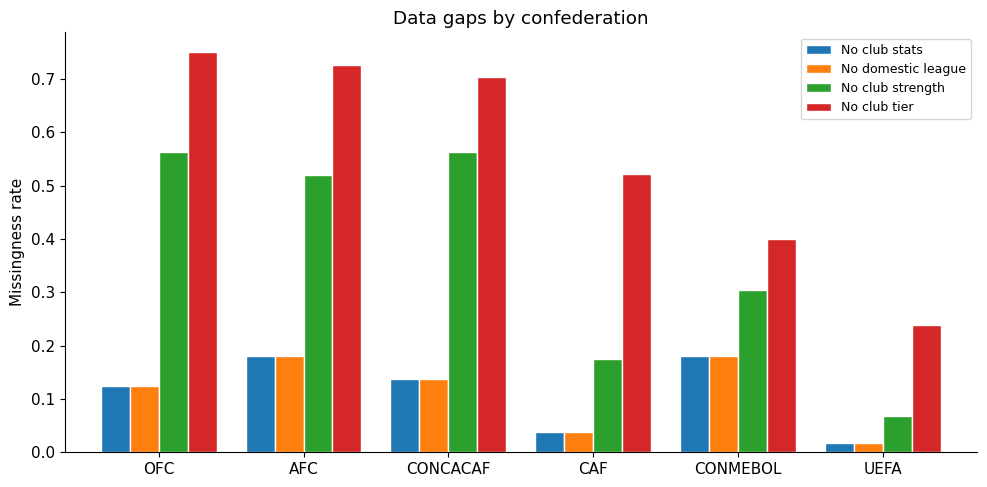

                    n_players  no_stats  no_league  no_club_strength  no_club_rank
confederation_code                                                                
OFC                        16     0.125      0.125             0.562         0.750
AFC                       350     0.180      0.180             0.520         0.726
CONCACAF                  297     0.138      0.138             0.562         0.704
CAF                       400     0.038      0.038             0.175         0.522
CONMEBOL                  454     0.181      0.181             0.304         0.401
UEFA                     1373     0.017      0.017             0.068         0.239


In [3]:
team_conf = teams_meta[
    ["team_name", "confederation_code", "region_name"]
].drop_duplicates()
miss_analysis = df.merge(
    team_conf, left_on="national_team", right_on="team_name", how="left"
)

miss_by_conf = (
    miss_analysis.groupby("confederation_code")
    .agg(
        n_players=("key_id", "count"),
        no_stats=("has_stats", lambda x: (~x).mean()),
        no_league=("has_domestic", lambda x: (~x).mean()),
        no_club_strength=("market_value", lambda x: x.isna().mean()),
        no_club_rank=("club_league_position", lambda x: x.isna().mean()),
    )
    .sort_values("no_club_rank", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
miss_by_conf[["no_stats", "no_league", "no_club_strength", "no_club_rank"]].plot(
    kind="bar", ax=ax, edgecolor="white", width=0.8
)
ax.set_ylabel("Missingness rate")
ax.set_title("Data gaps by confederation")
ax.set_xlabel("")
ax.legend(
    ["No club stats", "No domestic league", "No club strength", "No club tier"],
    fontsize=9,
)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(miss_by_conf.round(3).to_string())

**Fringe Player Audit**

Do the 8% of players without club stats actually play at the World Cup? If not, the missingness is irrelevant to match outcomes.

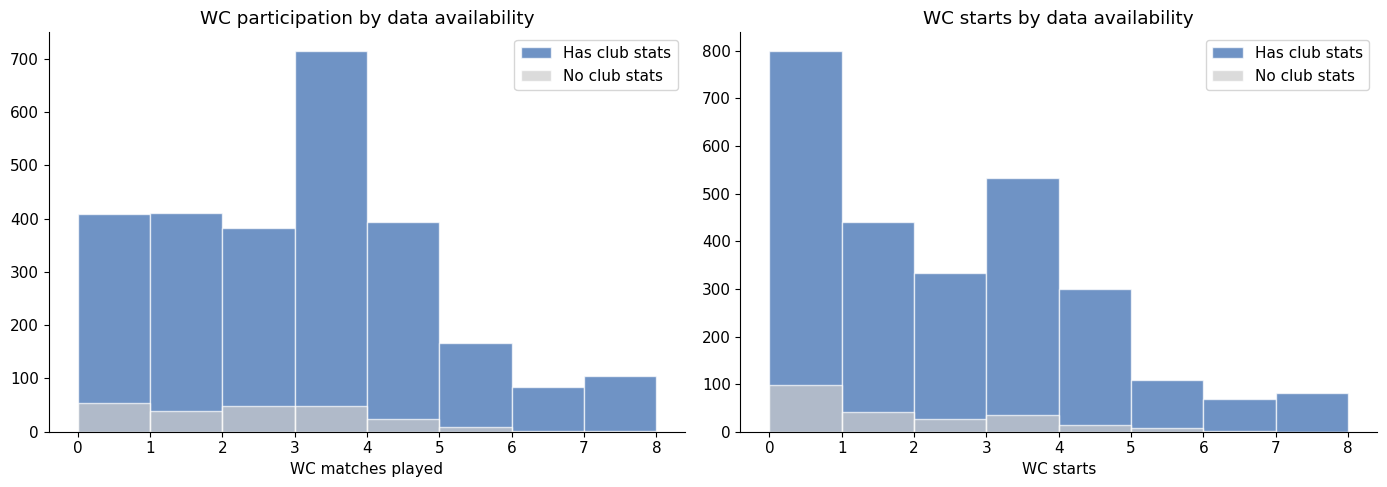

Players without club stats: 226
  Of those, played 0 WC matches: 54
  Played 1+ WC matches: 172
  Started 1+ WC matches: 127
  Scored at WC: 25


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WC matches played: players WITH stats vs WITHOUT
for has, color, label in [
    (True, "#3266ad", "Has club stats"),
    (False, "#cccccc", "No club stats"),
]:
    sub = df[df["has_stats"] == has]["matches_played"].fillna(0)
    axes[0].hist(
        sub, bins=range(0, 9), alpha=0.7, color=color, label=label, edgecolor="white"
    )
axes[0].set_xlabel("WC matches played")
axes[0].set_title("WC participation by data availability")
axes[0].legend()

# Starts
for has, color, label in [
    (True, "#3266ad", "Has club stats"),
    (False, "#cccccc", "No club stats"),
]:
    sub = df[df["has_stats"] == has]["starts"].fillna(0)
    axes[1].hist(
        sub, bins=range(0, 9), alpha=0.7, color=color, label=label, edgecolor="white"
    )
axes[1].set_xlabel("WC starts")
axes[1].set_title("WC starts by data availability")
axes[1].legend()

plt.tight_layout()
plt.show()

no_stats = df[df["has_stats"] == False]
print(f"Players without club stats: {len(no_stats)}")
print(f"  Of those, played 0 WC matches: {(no_stats['matches_played'] == 0).sum()}")
print(f"  Played 1+ WC matches: {(no_stats['matches_played'] > 0).sum()}")
print(f"  Started 1+ WC matches: {(no_stats['starts'] > 0).sum()}")
print(f"  Scored at WC: {(no_stats['wc_goals'] > 0).sum()}")

**Club and Competition Tier Coverage**

This repo version uses competition and club tiers as the available league-quality fields.

In [5]:
miss_rank = df[df["club_league_position"].isna() & (df["has_stats"] == True)]
print(f"Players with stats but no club_league_position: {len(miss_rank)}")
print(f"\nTheir leagues (top 15):")
print(miss_rank["league"].value_counts().head(15))
print(f"\nTheir league countries (top 10):")
print(miss_rank["league_country"].value_counts().head(10))
print(f"\nTheir confederations:")
miss_rank_conf = miss_rank.merge(
    team_conf, left_on="national_team", right_on="team_name", how="left"
)
print(miss_rank_conf["confederation_code"].value_counts())

Players with stats but no club_league_position: 968

Their leagues (top 15):
league
LaLiga                  66
AFC Champions League    65
Ligue 1                 60
Premier League          53
Serie A                 44
Premier Liga            39
Liga MX Clausura        38
Championship            36
Bundesliga              30
CONCACAF CL             21
Super League 1          20
Liga MX Apertura        18
Primera Apertura        18
Ligue 2                 18
Super League            16
Name: count, dtype: int64

Their league countries (top 10):
league_country
ENG    118
FRA     78
MEX     77
ESP     75
KOR     75
ITA     51
GER     44
RUS     39
AUS     24
BEL     22
Name: count, dtype: int64

Their confederations:
confederation_code
UEFA        305
CAF         194
AFC         191
CONCACAF    168
CONMEBOL    100
OFC          10
Name: count, dtype: int64


##### **Section 2 - Feature Distributions**

**Raw Stat Distributions**

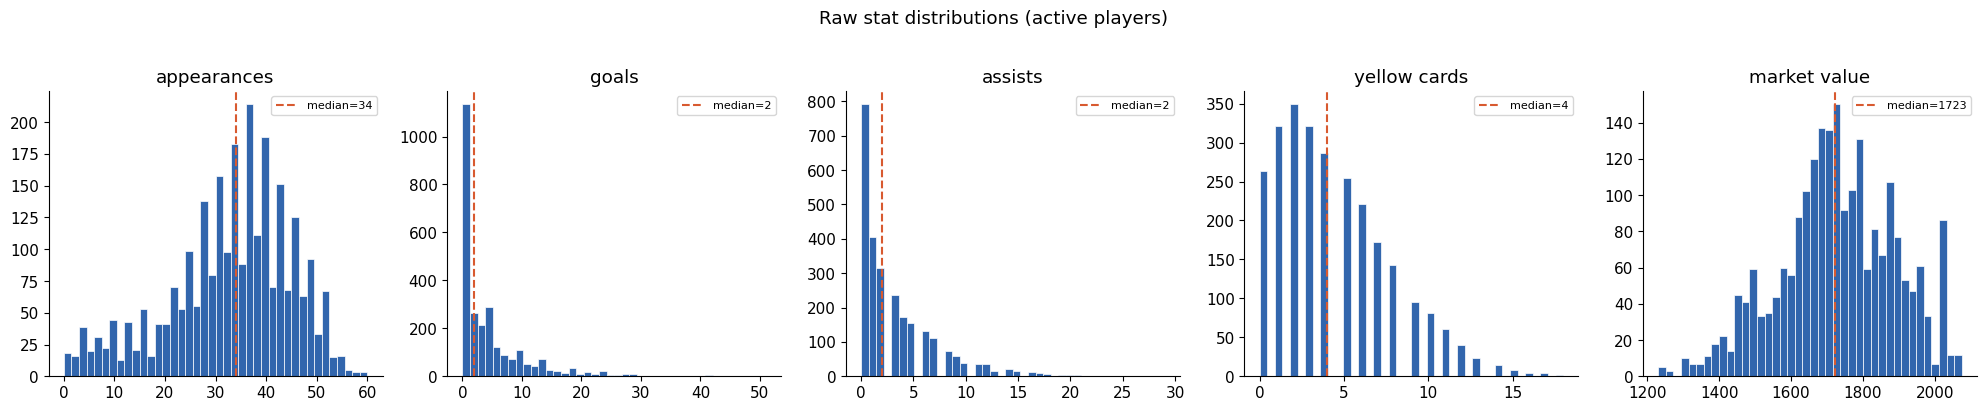

In [6]:
stat_cols = [
    "total_appearances",
    "total_goals",
    "total_assists",
    "total_yellow_cards",
    "market_value",
]

fig, axes = plt.subplots(1, len(stat_cols), figsize=(20, 4))
for ax, col in zip(axes, stat_cols):
    data = active[col].dropna()
    ax.hist(data, bins=40, color="#3266ad", edgecolor="white", linewidth=0.5)
    ax.axvline(
        data.median(),
        color="#D85A30",
        ls="--",
        linewidth=1.5,
        label=f"median={data.median():.0f}",
    )
    ax.set_title(col.replace("total_", "").replace("_", " "))
    ax.legend(fontsize=8)
fig.suptitle("Raw stat distributions (active players)", y=1.02)
plt.tight_layout()
plt.show()

**Per-Appearance Rates by Position**

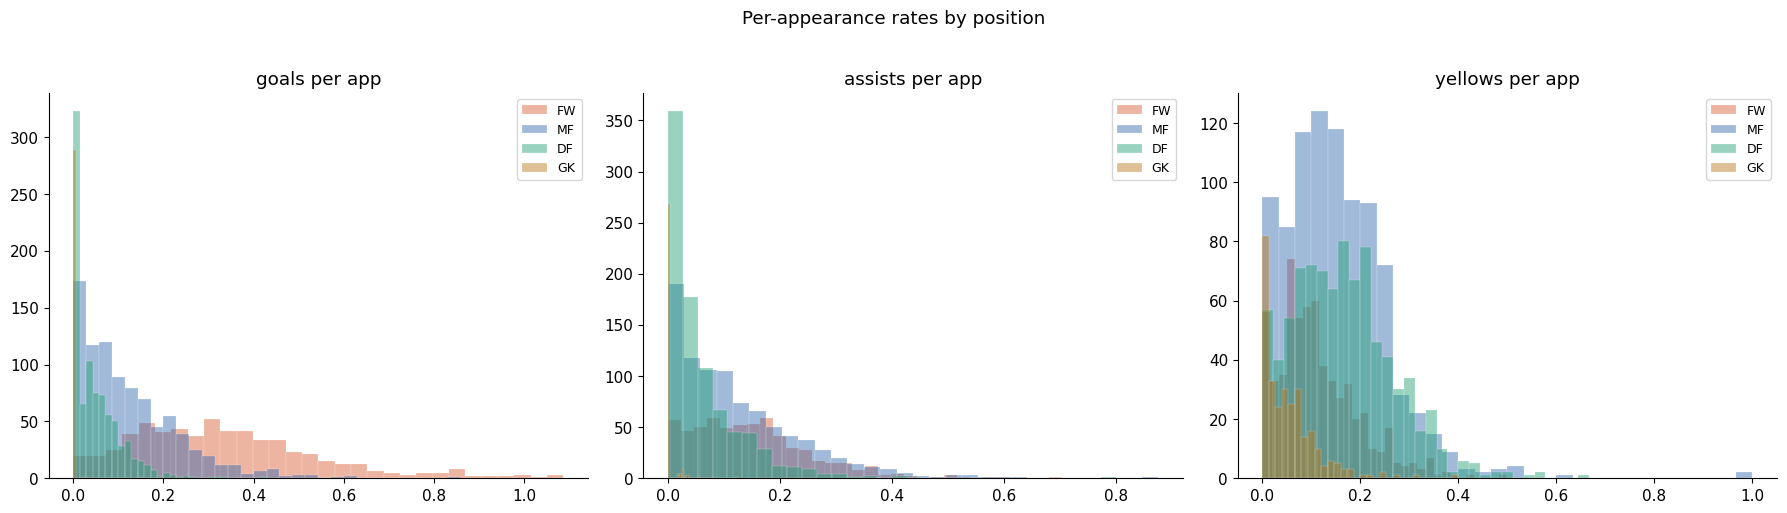

In [7]:
rate_cols = ["goals_per_app", "assists_per_app", "yellows_per_app"]

fig, axes = plt.subplots(1, len(rate_cols), figsize=(18, 5))
for ax, col in zip(axes, rate_cols):
    for pos in ["FW", "MF", "DF", "GK"]:
        sub = active[active["position_code"] == pos][col].dropna()
        ax.hist(
            sub,
            bins=30,
            alpha=0.45,
            label=pos,
            color=POS_COLORS[pos],
            edgecolor="white",
            linewidth=0.3,
        )
    ax.set_title(col.replace("_", " "))
    ax.legend(fontsize=9)
fig.suptitle("Per-appearance rates by position", y=1.02)
plt.tight_layout()
plt.show()

**Goalkeeper Distributions**

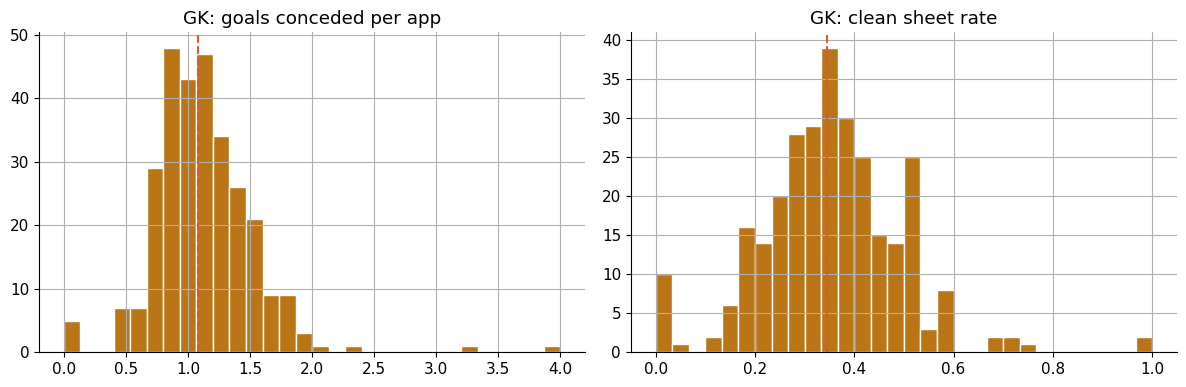

In [8]:
gk = active[active["position_code"] == "GK"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gk["goals_conceded_per_app"].dropna().hist(
    bins=30, ax=axes[0], color=POS_COLORS["GK"], edgecolor="white"
)
axes[0].set_title("GK: goals conceded per app")
axes[0].axvline(gk["goals_conceded_per_app"].median(), color="#D85A30", ls="--")

gk["clean_sheet_rate"].dropna().hist(
    bins=30, ax=axes[1], color=POS_COLORS["GK"], edgecolor="white"
)
axes[1].set_title("GK: clean sheet rate")
axes[1].axvline(gk["clean_sheet_rate"].median(), color="#D85A30", ls="--")

plt.tight_layout()
plt.show()

**Club Strength Across Tournaments**

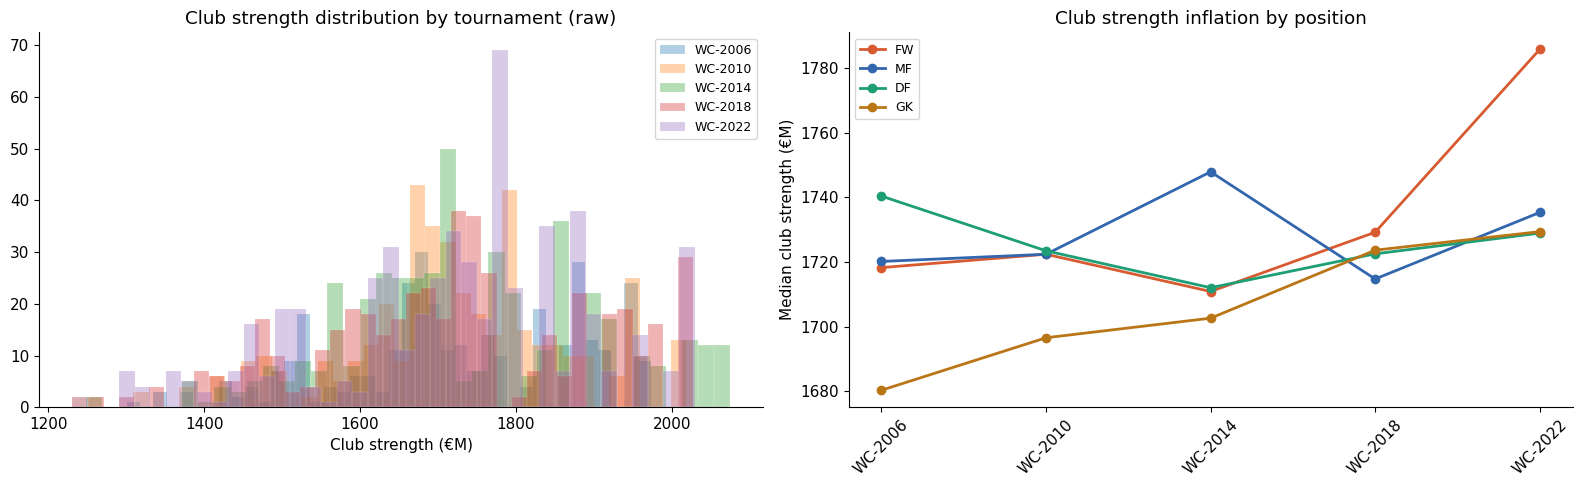

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution by tournament
for wc, color in [
    ("WC-2006", "#3266ad"),
    ("WC-2010", "#1D9E75"),
    ("WC-2014", "#D85A30"),
    ("WC-2018", "#BA7517"),
    ("WC-2022", "#7B5EA7"),
]:
    sub = active[(active["wc_tournament"] == wc) & (active["market_value"].notna())]
    axes[0].hist(
        sub["market_value"],
        bins=40,
        alpha=0.35,
        label=wc,
        edgecolor="white",
        linewidth=0.3,
    )
axes[0].set_xlabel("Club strength (\u20acM)")
axes[0].set_title("Club strength distribution by tournament (raw)")
axes[0].legend(fontsize=9)

# Median by tournament + position
for pos in ["FW", "MF", "DF", "GK"]:
    sub = active[active["position_code"] == pos]
    medians = sub.groupby("wc_tournament")["market_value"].median()
    axes[1].plot(
        medians.index,
        medians.values,
        marker="o",
        label=pos,
        color=POS_COLORS[pos],
        linewidth=2,
    )
axes[1].set_ylabel("Median club strength (\u20acM)")
axes[1].set_title("Club strength inflation by position")
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Club Strength as Validation Layer**

High goals_per_app + low club strength may indicate inflated stats from weaker leagues.

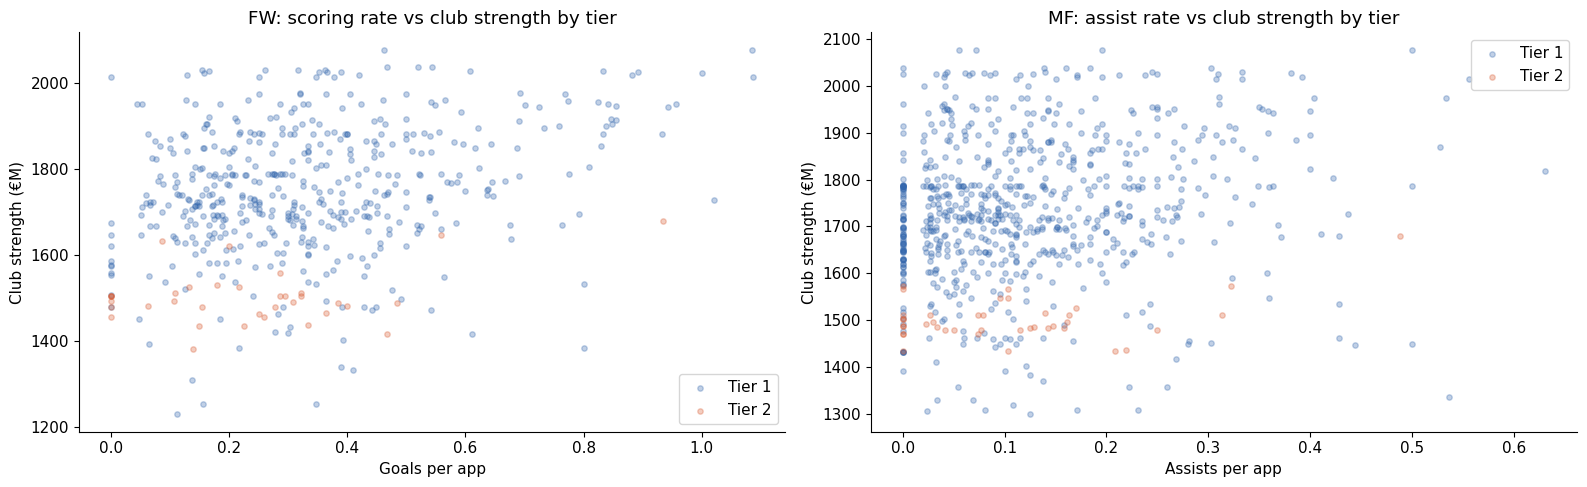

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fw = active[active["position_code"] == "FW"].copy()

# Goals per app vs club strength — color by league tier
for tier, color, label in [(1, "#3266ad", "Tier 1"), (2, "#D85A30", "Tier 2")]:
    sub = fw[fw["league_tier"] == tier]
    axes[0].scatter(
        sub["goals_per_app"],
        sub["market_value"],
        alpha=0.3,
        s=15,
        c=color,
        label=label,
    )
axes[0].set_xlabel("Goals per app")
axes[0].set_ylabel("Club strength (\u20acM)")
axes[0].set_title("FW: scoring rate vs club strength by tier")
axes[0].legend()

# Assists per app vs club strength — midfielders
mf = active[active["position_code"] == "MF"].copy()
for tier, color, label in [(1, "#3266ad", "Tier 1"), (2, "#D85A30", "Tier 2")]:
    sub = mf[mf["league_tier"] == tier]
    axes[1].scatter(
        sub["assists_per_app"],
        sub["market_value"],
        alpha=0.3,
        s=15,
        c=color,
        label=label,
    )
axes[1].set_xlabel("Assists per app")
axes[1].set_ylabel("Club strength (\u20acM)")
axes[1].set_title("MF: assist rate vs club strength by tier")
axes[1].legend()

plt.tight_layout()
plt.show()

##### **Section 3 - League Quality Analysis**

Is a goal in the Championship worth the same as one in La Liga?

**Scoring Rates by League Tier**

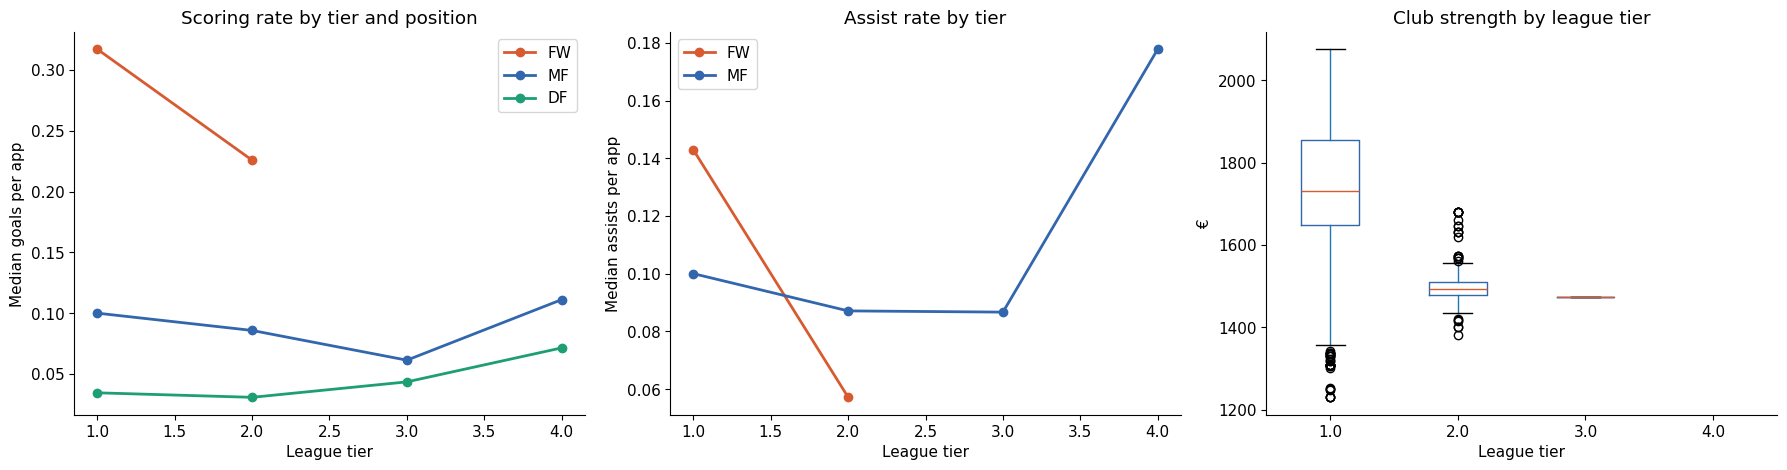

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Goals per app by tier + position
for pos in ["FW", "MF", "DF"]:
    sub = active[(active["position_code"] == pos) & (active["league_tier"].notna())]
    grouped = sub.groupby("league_tier")["goals_per_app"].agg(
        ["median", "mean", "count"]
    )
    axes[0].plot(
        grouped.index,
        grouped["median"],
        marker="o",
        label=pos,
        color=POS_COLORS[pos],
        linewidth=2,
    )
axes[0].set_xlabel("League tier")
axes[0].set_ylabel("Median goals per app")
axes[0].set_title("Scoring rate by tier and position")
axes[0].legend()

# Assists per app by tier
for pos in ["FW", "MF"]:
    sub = active[(active["position_code"] == pos) & (active["league_tier"].notna())]
    grouped = sub.groupby("league_tier")["assists_per_app"].median()
    axes[1].plot(
        grouped.index,
        grouped.values,
        marker="o",
        label=pos,
        color=POS_COLORS[pos],
        linewidth=2,
    )
axes[1].set_xlabel("League tier")
axes[1].set_ylabel("Median assists per app")
axes[1].set_title("Assist rate by tier")
axes[1].legend()

# Club strength by tier
active.boxplot(
    column="market_value",
    by="league_tier",
    ax=axes[2],
    grid=False,
    boxprops=dict(color="#3266ad"),
    medianprops=dict(color="#D85A30"),
)
axes[2].set_title("Club strength by league tier")
axes[2].set_xlabel("League tier")
axes[2].set_ylabel("\u20ac")
axes[2].get_figure().suptitle("")

plt.tight_layout()
plt.show()

**Club Scoring vs World Cup Scoring**

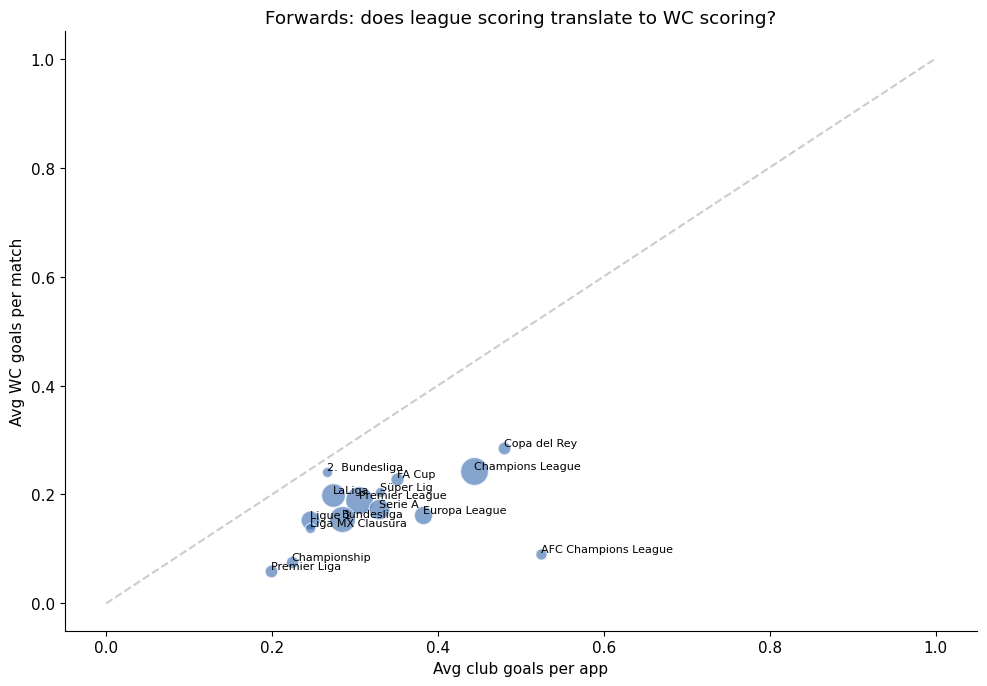

                       n  club_scoring  wc_scoring    avg_mv
home_league                                                 
Copa del Rey          14         0.479       0.285  1960.336
Champions League      67         0.444       0.243  1852.046
2. Bundesliga          9         0.267       0.241  1482.016
FA Cup                15         0.351       0.228  1914.545
Süper Lig              9         0.330       0.204  1591.166
LaLiga                49         0.273       0.200  1813.653
Premier League        66         0.306       0.190  1797.592
Serie A               37         0.329       0.174  1738.535
Europa League         29         0.383       0.162  1744.925
Bundesliga            59         0.284       0.155  1718.692
Ligue 1               31         0.246       0.153  1704.299
Liga MX Clausura       9         0.245       0.139       NaN
AFC Champions League  11         0.524       0.091       NaN
Championship          13         0.224       0.077  1525.872
Premier Liga          14

In [12]:
played = active[active["matches_played"] > 0].copy()
played["wc_goals_per_match"] = played["wc_goals"] / played["matches_played"]

fw_played = played[played["position_code"] == "FW"]
league_comp = (
    fw_played.groupby("home_league")
    .agg(
        n=("key_id", "count"),
        club_scoring=("goals_per_app", "mean"),
        wc_scoring=("wc_goals_per_match", "mean"),
        avg_mv=("market_value", "mean"),
    )
    .query("n >= 8")
    .sort_values("wc_scoring", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in league_comp.iterrows():
    ax.scatter(
        row["club_scoring"],
        row["wc_scoring"],
        s=row["n"] * 6,
        alpha=0.6,
        c="#3266ad",
        edgecolors="white",
    )
    ax.annotate(
        row.name,
        (row["club_scoring"], row["wc_scoring"]),
        fontsize=8,
        ha="left",
        va="bottom",
    )

ax.plot([0, 1], [0, 1], ls="--", color="gray", alpha=0.4)
ax.set_xlabel("Avg club goals per app")
ax.set_ylabel("Avg WC goals per match")
ax.set_title("Forwards: does league scoring translate to WC scoring?")
plt.tight_layout()
plt.show()

print(league_comp.round(3).to_string())

**League Country Contribution**

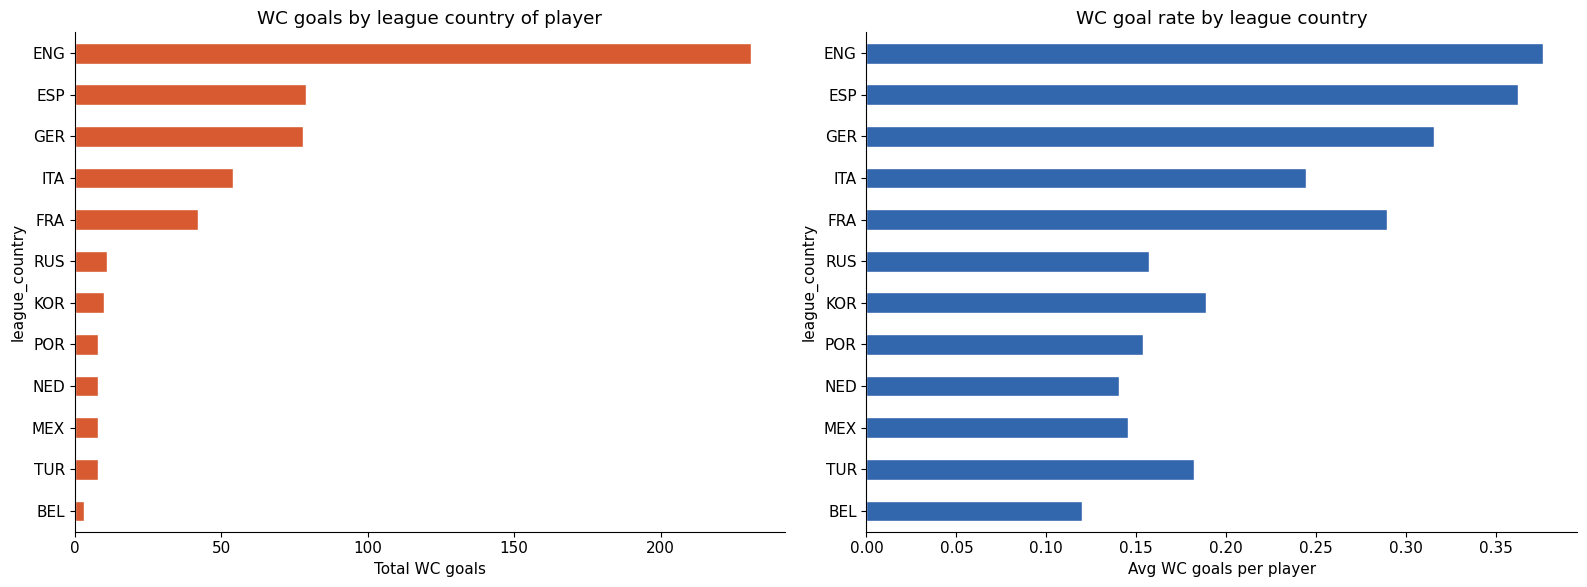

In [13]:
country_wc = (
    played.groupby("league_country")
    .agg(
        n_players=("key_id", "count"),
        total_wc_goals=("wc_goals", "sum"),
        avg_wc_goals=("wc_goals", "mean"),
        avg_club_goals_per_app=("goals_per_app", "mean"),
    )
    .sort_values("total_wc_goals", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_wc.head(12)["total_wc_goals"].plot(
    kind="barh", ax=axes[0], color="#D85A30", edgecolor="white"
)
axes[0].set_xlabel("Total WC goals")
axes[0].set_title("WC goals by league country of player")
axes[0].invert_yaxis()

country_wc.head(12)["avg_wc_goals"].plot(
    kind="barh", ax=axes[1], color="#3266ad", edgecolor="white"
)
axes[1].set_xlabel("Avg WC goals per player")
axes[1].set_title("WC goal rate by league country")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

##### **Section 4 - Player-to-Team Bridge**

The modeling unit is a match between two teams, not individual players. This section aggregates player stats to the squad level.

**Appearance-Weighted Squad Aggregation**

In [14]:
def weighted_mean(group, col, weight_col="total_appearances"):
    w = group[weight_col].fillna(0)
    v = group[col].fillna(0)
    if w.sum() == 0:
        return np.nan
    return np.average(v, weights=w)


team_features = []
for (wc, team), grp in active.groupby(["wc_tournament", "national_team"]):
    row = {"wc_tournament": wc, "national_team": team, "squad_size": len(grp)}

    # Squad-wide weighted averages
    for col in [
        "goals_per_app",
        "assists_per_app",
        "yellows_per_app",
        "goals_conceded_per_app",
        "clean_sheet_rate",
    ]:
        row[f"squad_{col}"] = weighted_mean(grp, col)

    # Squad-wide simple averages / sums
    row["squad_avg_mv"] = grp["market_value"].mean()
    row["squad_total_mv"] = grp["market_value"].sum()
    row["squad_avg_club_pos"] = grp["club_league_position"].mean()
    row["squad_mv_std"] = grp["market_value"].std()

    # Positional group aggregates
    for pos in ["FW", "MF", "DF", "GK"]:
        pg = grp[grp["position_code"] == pos]
        row[f"{pos}_count"] = len(pg)
        row[f"{pos}_avg_goals_per_app"] = (
            weighted_mean(pg, "goals_per_app") if len(pg) > 0 else np.nan
        )
        row[f"{pos}_avg_assists_per_app"] = (
            weighted_mean(pg, "assists_per_app") if len(pg) > 0 else np.nan
        )
        row[f"{pos}_avg_mv"] = pg["market_value"].mean() if len(pg) > 0 else np.nan

    # GK-specific
    gk_grp = grp[grp["position_code"] == "GK"]
    row["GK_avg_clean_sheet_rate"] = (
        weighted_mean(gk_grp, "clean_sheet_rate") if len(gk_grp) > 0 else np.nan
    )
    row["GK_avg_conceded_per_app"] = (
        weighted_mean(gk_grp, "goals_conceded_per_app") if len(gk_grp) > 0 else np.nan
    )

    # WC outcome
    row["wc_goals_scored"] = grp["wc_goals"].sum()
    row["wc_matches"] = grp["matches_played"].max()

    team_features.append(row)

team_df = pd.DataFrame(team_features)

# Add best WC stage reached
team_results = []
for _, m in wc_matches.iterrows():
    for side in ["home", "away"]:
        team_results.append(
            {
                "wc_tournament": m["tournament_id"],
                "national_team": m[f"team_name_{side}"],
                "stage_num": STAGE_ORDER.get(m["stage_name"].lower(), 0),
            }
        )
team_results = pd.DataFrame(team_results)
best_stage = (
    team_results.groupby(["wc_tournament", "national_team"])["stage_num"]
    .max()
    .reset_index()
)
best_stage.columns = ["wc_tournament", "national_team", "best_stage"]
team_df = team_df.merge(best_stage, on=["wc_tournament", "national_team"], how="left")

print(f"Team-level dataset: {team_df.shape}")
print(f"\nTop 5 squads by avg club strength:")
print(
    team_df.nlargest(5, "squad_avg_mv")[
        [
            "wc_tournament",
            "national_team",
            "squad_size",
            "squad_goals_per_app",
            "squad_avg_mv",
            "FW_avg_goals_per_app",
            "wc_goals_scored",
            "best_stage",
        ]
    ].to_string(index=False)
)

Team-level dataset: (158, 33)

Top 5 squads by avg club strength:
wc_tournament national_team  squad_size  squad_goals_per_app  squad_avg_mv  FW_avg_goals_per_app  wc_goals_scored  best_stage
      WC-2014         Spain          22             0.151452   1968.025921              0.417526                4           0
      WC-2018         Spain          20             0.137615   1932.670766              0.343590                5           1
      WC-2018        Brazil          19             0.195244   1914.709220              0.406699                8           2
      WC-2010         Spain          21             0.190223   1899.924406              0.522472                8           4
      WC-2014       Germany          23             0.126667   1886.984640              0.369128               18           4


**Positional Profiles by Team Progression**

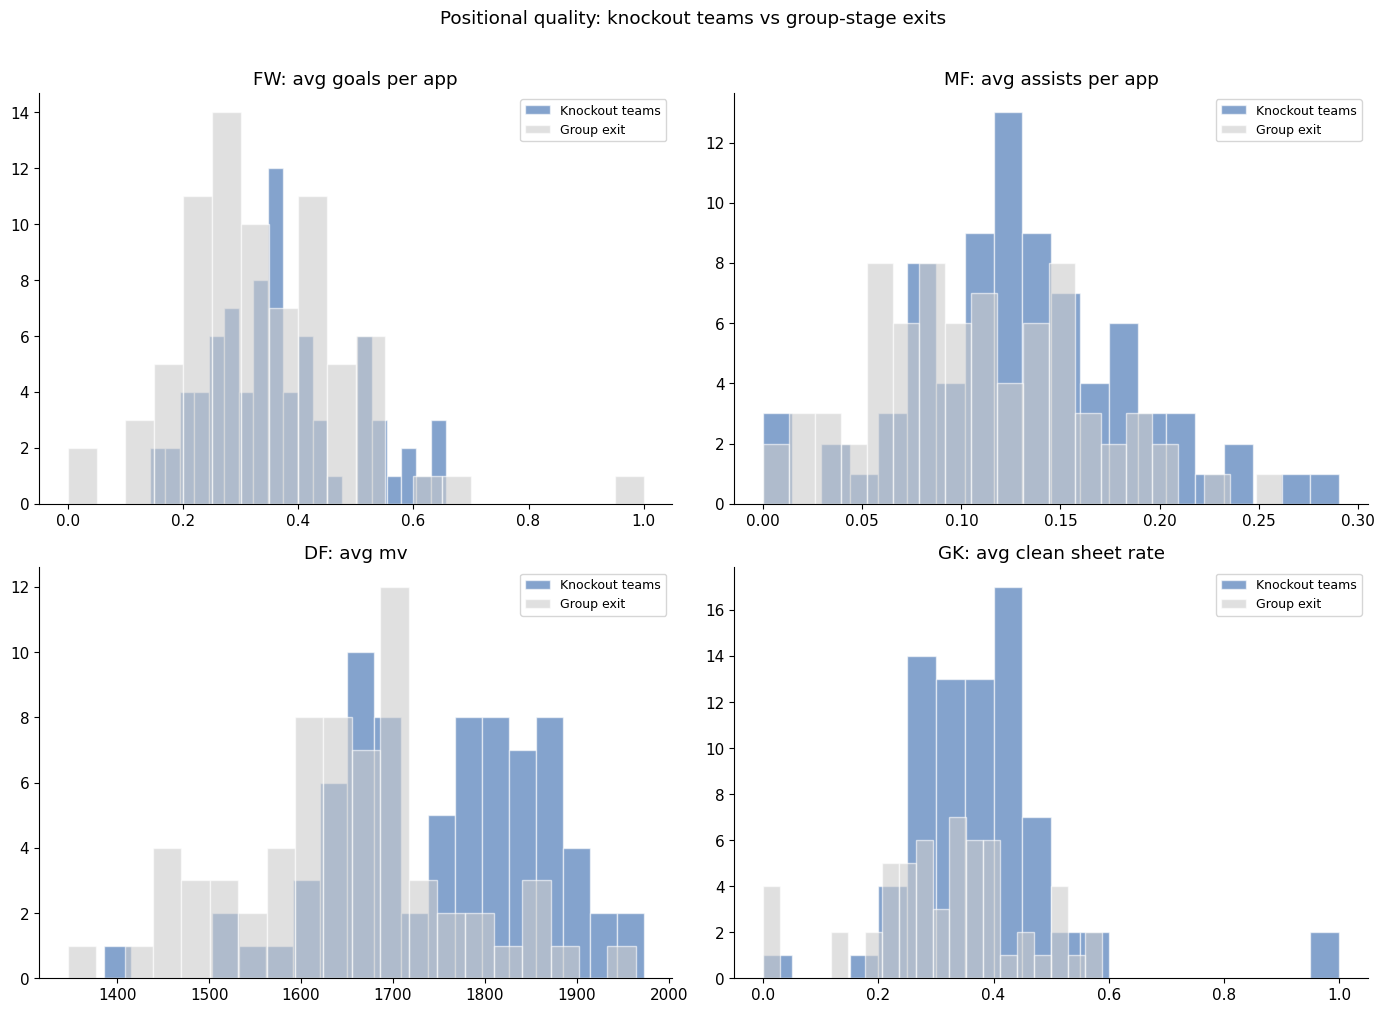

                         Group exit   Knockout
FW_avg_goals_per_app         0.3194     0.3516
MF_avg_assists_per_app       0.1039     0.1253
DF_avg_mv                 1653.0176  1766.7928
GK_avg_clean_sheet_rate      0.3333     0.3660
squad_avg_mv              1650.3572  1741.9566


In [15]:
# Split into teams that reached knockouts vs group-stage exits
team_df["advanced"] = team_df["best_stage"] >= 1  # at least round of 16

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (pos, stat) in zip(
    axes.flat,
    [
        ("FW", "FW_avg_goals_per_app"),
        ("MF", "MF_avg_assists_per_app"),
        ("DF", "DF_avg_mv"),
        ("GK", "GK_avg_clean_sheet_rate"),
    ],
):
    for adv, color, label in [
        (True, "#3266ad", "Knockout teams"),
        (False, "#cccccc", "Group exit"),
    ]:
        sub = team_df[team_df["advanced"] == adv][stat].dropna()
        ax.hist(sub, bins=20, alpha=0.6, color=color, label=label, edgecolor="white")
    ax.set_title(f"{pos}: {stat.split('_', 1)[1].replace('_', ' ')}")
    ax.legend(fontsize=9)

plt.suptitle("Positional quality: knockout teams vs group-stage exits", y=1.01)
plt.tight_layout()
plt.show()

# Summary table
profile = (
    team_df.groupby("advanced")
    .agg(
        {
            "FW_avg_goals_per_app": "median",
            "MF_avg_assists_per_app": "median",
            "DF_avg_mv": "median",
            "GK_avg_clean_sheet_rate": "median",
            "squad_avg_mv": "median",
        }
    )
    .round(4)
)
profile.index = ["Group exit", "Knockout"]
print(profile.T.to_string())

**Squad Concentration**

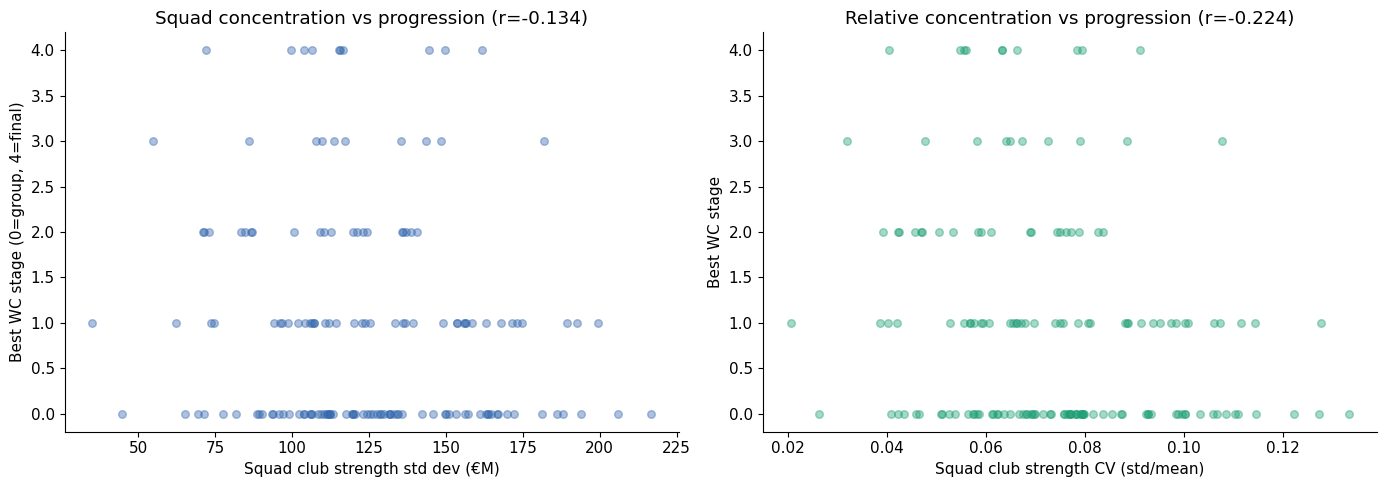

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Club strength std (concentration) vs best stage
axes[0].scatter(
    team_df["squad_mv_std"], team_df["best_stage"], alpha=0.4, s=30, c="#3266ad"
)
corr_conc = team_df[["squad_mv_std", "best_stage"]].dropna().corr().iloc[0, 1]
axes[0].set_xlabel("Squad club strength std dev (\u20acM)")
axes[0].set_ylabel("Best WC stage (0=group, 4=final)")
axes[0].set_title(f"Squad concentration vs progression (r={corr_conc:.3f})")

# Coefficient of variation (normalized spread)
team_df["squad_mv_cv"] = team_df["squad_mv_std"] / team_df["squad_avg_mv"]
axes[1].scatter(
    team_df["squad_mv_cv"], team_df["best_stage"], alpha=0.4, s=30, c="#1D9E75"
)
corr_cv = team_df[["squad_mv_cv", "best_stage"]].dropna().corr().iloc[0, 1]
axes[1].set_xlabel("Squad club strength CV (std/mean)")
axes[1].set_ylabel("Best WC stage")
axes[1].set_title(f"Relative concentration vs progression (r={corr_cv:.3f})")

plt.tight_layout()
plt.show()

**Top Club-Strength Players by Tournament**

In [17]:
stars = (
    active[active["market_value"].notna()]
    .sort_values(["wc_tournament", "market_value"], ascending=[True, False])
    .groupby("wc_tournament")
    .head(5)
)

for wc in sorted(stars["wc_tournament"].unique()):
    print(f"\n{wc}:")
    sub = stars[stars["wc_tournament"] == wc]
    print(
        sub[
            [
                "family_name",
                "national_team",
                "club",
                "position_code",
                "market_value",
                "goals_per_app",
                "wc_goals",
                "matches_played",
            ]
        ].to_string(index=False)
    )


WC-2006:
    family_name national_team         club position_code  market_value  goals_per_app  wc_goals  matches_played
          Messi     Argentina FC Barcelona            FW   1972.826538       0.320000         1               3
     Ronaldinho        Brazil FC Barcelona            MF   1972.826538       0.577778         0               5
        Márquez        Mexico FC Barcelona            DF   1972.826538       0.027027         1               4
van Bronckhorst   Netherlands FC Barcelona            DF   1972.826538       0.027778         0               3
           Deco      Portugal FC Barcelona            MF   1972.826538       0.116279         1               4

WC-2010:
family_name national_team         club position_code  market_value  goals_per_app  wc_goals  matches_played
      Messi     Argentina FC Barcelona            FW   2018.152466       0.882353         0               5
      Alves        Brazil FC Barcelona            DF   2018.152466       0.065217         0 

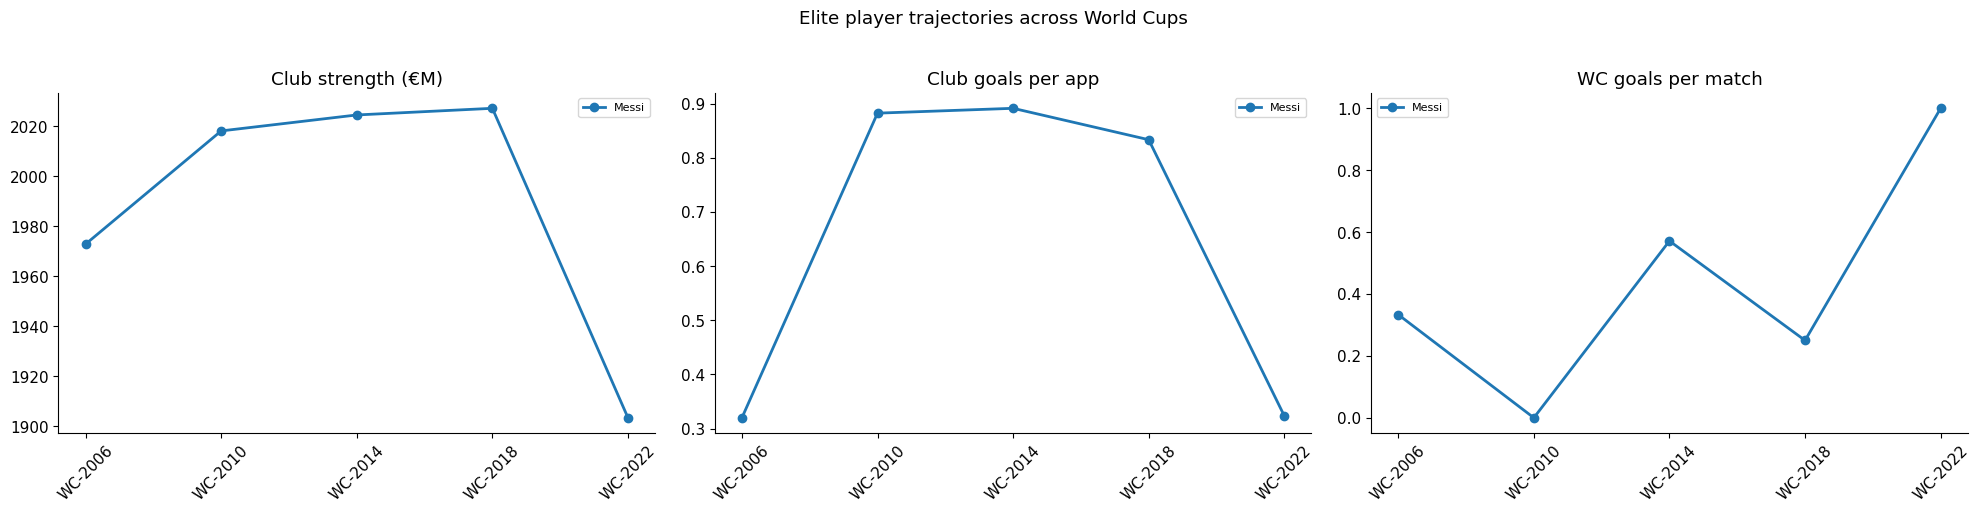

In [18]:
# Track repeat elite across tournaments
star_names = stars["family_name"].value_counts()
repeats = star_names[star_names > 1].index.tolist()
repeat_df = active[active["family_name"].isin(repeats)].sort_values(
    ["family_name", "wc_tournament"]
)

repeat_df["wc_goals_per_match"] = repeat_df["wc_goals"] / repeat_df[
    "matches_played"
].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name in repeats:
    s = repeat_df[repeat_df["family_name"] == name].sort_values("wc_tournament")
    if len(s) > 1:
        axes[0].plot(
            s["wc_tournament"],
            s["market_value"],
            marker="o",
            label=name,
            linewidth=2,
        )
        axes[1].plot(
            s["wc_tournament"], s["goals_per_app"], marker="o", label=name, linewidth=2
        )
        axes[2].plot(
            s["wc_tournament"],
            s["wc_goals_per_match"],
            marker="o",
            label=name,
            linewidth=2,
        )

axes[0].set_title("Club strength (\u20acM)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)
axes[1].set_title("Club goals per app")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)
axes[2].set_title("WC goals per match")
axes[2].legend(fontsize=8)
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Elite player trajectories across World Cups", y=1.02)
plt.tight_layout()
plt.show()

##### **Section 5 - Competitive Differentials**

The model's actual input is the gap between two squads. This section builds pairwise differentials and tests their relationship with match outcomes.

**Build Match-Level Differentials**

In [19]:
def compute_differentials(match_df, team_df, features):
    """For each match, compute Team_Home - Team_Away for each feature."""
    rows = []
    for _, m in match_df.iterrows():
        wc = m["tournament_id"]
        home = m["team_name_home"]
        away = m["team_name_away"]

        home_row = team_df[
            (team_df["wc_tournament"] == wc) & (team_df["national_team"] == home)
        ]
        away_row = team_df[
            (team_df["wc_tournament"] == wc) & (team_df["national_team"] == away)
        ]

        if len(home_row) == 0 or len(away_row) == 0:
            continue

        row = {
            "match_id": m["match_id"],
            "wc_tournament": wc,
            "home_team": home,
            "away_team": away,
            "goal_diff": m["goals_for_home"] - m["goals_for_away"],
            "result_home": m["result_home"],
            "stage": m["stage_name"],
        }

        for feat in features:
            h = home_row.iloc[0].get(feat, np.nan)
            a = away_row.iloc[0].get(feat, np.nan)
            if pd.notna(h) and pd.notna(a):
                row[f"diff_{feat}"] = h - a
            else:
                row[f"diff_{feat}"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


diff_features = [
    "squad_goals_per_app",
    "squad_assists_per_app",
    "squad_avg_mv",
    "squad_avg_club_pos",
    "squad_yellows_per_app",
    "squad_clean_sheet_rate",
    "squad_goals_conceded_per_app",
    "FW_avg_goals_per_app",
    "MF_avg_assists_per_app",
    "DF_avg_mv",
    "GK_avg_clean_sheet_rate",
    "GK_avg_conceded_per_app",
    "FW_avg_mv",
    "MF_avg_mv",
    "squad_mv_cv",
]

diff_df = compute_differentials(wc_matches, team_df, diff_features)
print(f"Match differentials: {diff_df.shape}")
print(f"Result distribution:\n{diff_df['result_home'].value_counts()}")

Match differentials: (314, 22)
Result distribution:
result_home
W    146
L    116
D     52
Name: count, dtype: int64


**Differential vs Outcome**

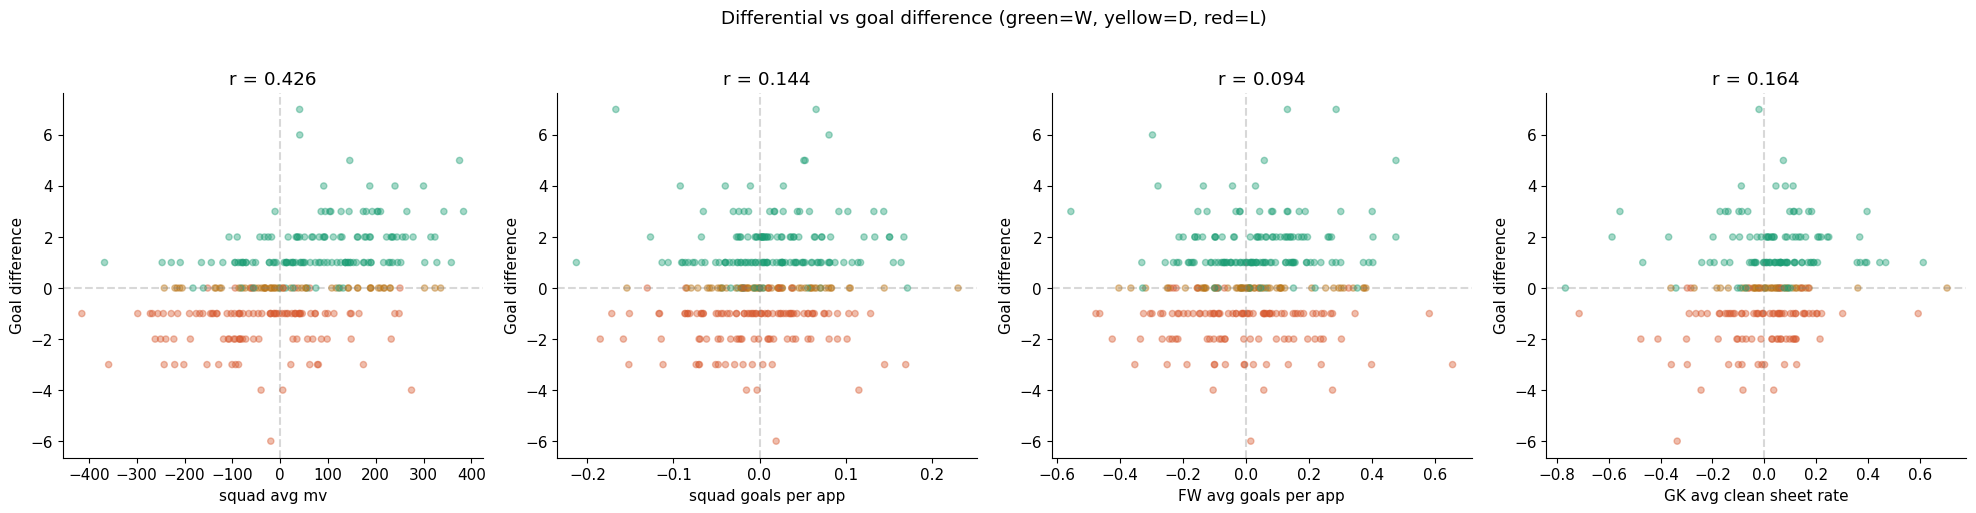

In [20]:
key_diffs = [
    "diff_squad_avg_mv",
    "diff_squad_goals_per_app",
    "diff_FW_avg_goals_per_app",
    "diff_GK_avg_clean_sheet_rate",
]

fig, axes = plt.subplots(1, len(key_diffs), figsize=(20, 5))

for ax, col in zip(axes, key_diffs):
    sub = diff_df.dropna(subset=[col])
    colors = sub["result_home"].map({"W": "#1D9E75", "D": "#BA7517", "L": "#D85A30"})
    ax.scatter(sub[col], sub["goal_diff"], alpha=0.4, s=20, c=colors)
    corr = sub[[col, "goal_diff"]].corr().iloc[0, 1]
    ax.axhline(0, color="gray", ls="--", alpha=0.3)
    ax.axvline(0, color="gray", ls="--", alpha=0.3)
    ax.set_xlabel(col.replace("diff_", "").replace("_", " "))
    ax.set_ylabel("Goal difference")
    ax.set_title(f"r = {corr:.3f}")

plt.suptitle("Differential vs goal difference (green=W, yellow=D, red=L)", y=1.02)
plt.tight_layout()
plt.show()

**Signal Strength: Offensive, Defensive, and Club Strength**

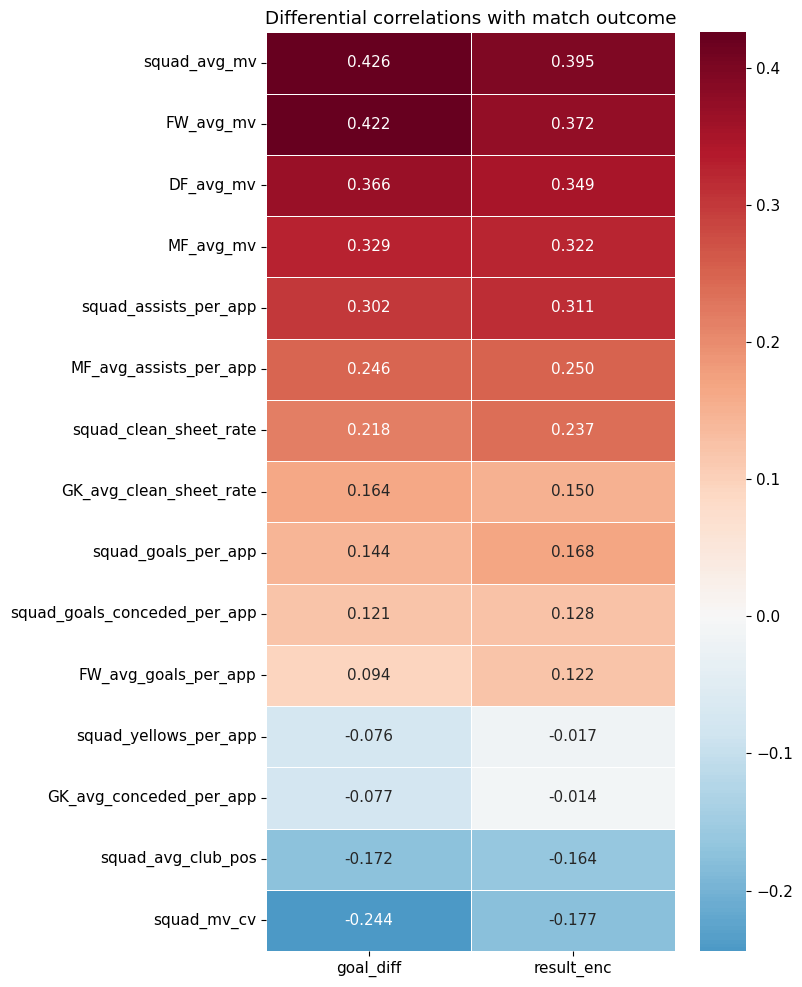


Ranked by |correlation with goal_diff|:
squad_avg_mv                    0.426
FW_avg_mv                       0.422
DF_avg_mv                       0.366
MF_avg_mv                       0.329
squad_assists_per_app           0.302
MF_avg_assists_per_app          0.246
squad_mv_cv                     0.244
squad_clean_sheet_rate          0.218
squad_avg_club_pos              0.172
GK_avg_clean_sheet_rate         0.164
squad_goals_per_app             0.144
squad_goals_conceded_per_app    0.121
FW_avg_goals_per_app            0.094
GK_avg_conceded_per_app         0.077
squad_yellows_per_app           0.076


In [21]:
# Correlation heatmap: all differentials vs goal difference and result
diff_cols = [c for c in diff_df.columns if c.startswith("diff_")]

# Encode result: W=1, D=0, L=-1
diff_df["result_enc"] = diff_df["result_home"].map({"W": 1, "D": 0, "L": -1})

corr_target = diff_df[diff_cols + ["goal_diff", "result_enc"]].corr()[
    ["goal_diff", "result_enc"]
]
corr_target = corr_target.drop(["goal_diff", "result_enc"], errors="ignore")
corr_target.index = [c.replace("diff_", "") for c in corr_target.index]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    corr_target.sort_values("goal_diff", ascending=False),
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Differential correlations with match outcome")
plt.tight_layout()
plt.show()

print("\nRanked by |correlation with goal_diff|:")
print(corr_target["goal_diff"].abs().sort_values(ascending=False).round(3).to_string())

**Draw Analysis**

Draws are the hardest outcome to predict. What do the differentials look like when the match ends level?

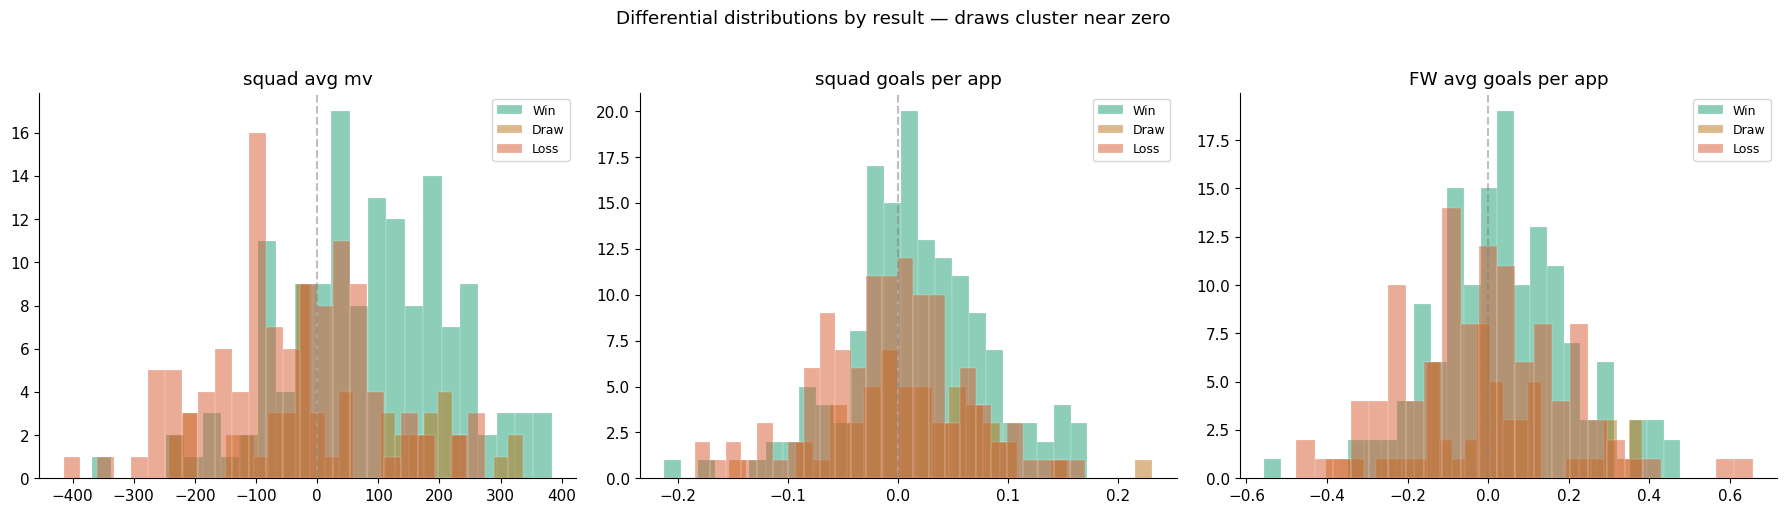


diff_squad_avg_mv:
              median     mean       std
result_home                            
D            -3.1024  33.7429  148.8855
L           -45.8315 -45.8754  134.1289
W            90.7228  85.0546  135.9992

diff_squad_goals_per_app:
             median    mean     std
result_home                        
D            0.0100  0.0147  0.0645
L           -0.0053 -0.0086  0.0674
W            0.0092  0.0165  0.0648

diff_FW_avg_goals_per_app:
             median    mean     std
result_home                        
D            0.0059  0.0185  0.1880
L           -0.0097 -0.0131  0.2030
W            0.0338  0.0373  0.1718


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(
    axes, ["diff_squad_avg_mv", "diff_squad_goals_per_app", "diff_FW_avg_goals_per_app"]
):
    for result, color, label in [
        ("W", "#1D9E75", "Win"),
        ("D", "#BA7517", "Draw"),
        ("L", "#D85A30", "Loss"),
    ]:
        sub = diff_df[diff_df["result_home"] == result][col].dropna()
        ax.hist(
            sub,
            bins=25,
            alpha=0.5,
            color=color,
            label=label,
            edgecolor="white",
            linewidth=0.3,
        )
    ax.set_title(col.replace("diff_", "").replace("_", " "))
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle("Differential distributions by result — draws cluster near zero", y=1.02)
plt.tight_layout()
plt.show()

# Median absolute differential by result
for col in [
    "diff_squad_avg_mv",
    "diff_squad_goals_per_app",
    "diff_FW_avg_goals_per_app",
]:
    print(f"\n{col}:")
    print(
        diff_df.groupby("result_home")[col]
        .agg(["median", "mean", "std"])
        .round(4)
        .to_string()
    )

##### **Section 6 - Institutional Benchmarking**

Does the player-aggregated data actually beat simple rankings?

**Merge Elo Ratings**

In [23]:
# Elo: get rating for each team in the WC year
team_df["wc_year"] = team_df["wc_tournament"].map(WC_YEAR)
team_df["elo_team"] = team_df["national_team"].replace(TEAM_NAME_FIX)

elo_merge = elo[["year", "team", "rating", "rank"]].rename(
    columns={
        "year": "wc_year",
        "team": "elo_team",
        "rating": "elo_rating",
        "rank": "elo_rank",
    }
)
team_df = team_df.merge(elo_merge, on=["wc_year", "elo_team"], how="left")

print(f"Elo coverage: {team_df['elo_rating'].notna().sum()}/{len(team_df)}")

Elo coverage: 158/158


**Player Stats vs Elo vs Tournament Outcome**

In [24]:
# Correlations: what predicts best_stage?
benchmark_cols = [
    "squad_avg_mv",
    "squad_goals_per_app",
    "FW_avg_goals_per_app",
    "GK_avg_clean_sheet_rate",
    "squad_avg_club_pos",
    "elo_rating",
]

corr_bench = (
    team_df[benchmark_cols + ["best_stage"]].corr()["best_stage"].drop("best_stage")
)

print("=== Correlation with WC progression (best_stage) ===")
print("  (negative for rank-based metrics means lower rank = better)")
print(corr_bench.sort_values(ascending=False).round(3).to_string())

=== Correlation with WC progression (best_stage) ===
  (negative for rank-based metrics means lower rank = better)
elo_rating                 0.708
squad_avg_mv               0.491
squad_goals_per_app        0.219
GK_avg_clean_sheet_rate    0.194
FW_avg_goals_per_app       0.192
squad_avg_club_pos        -0.216


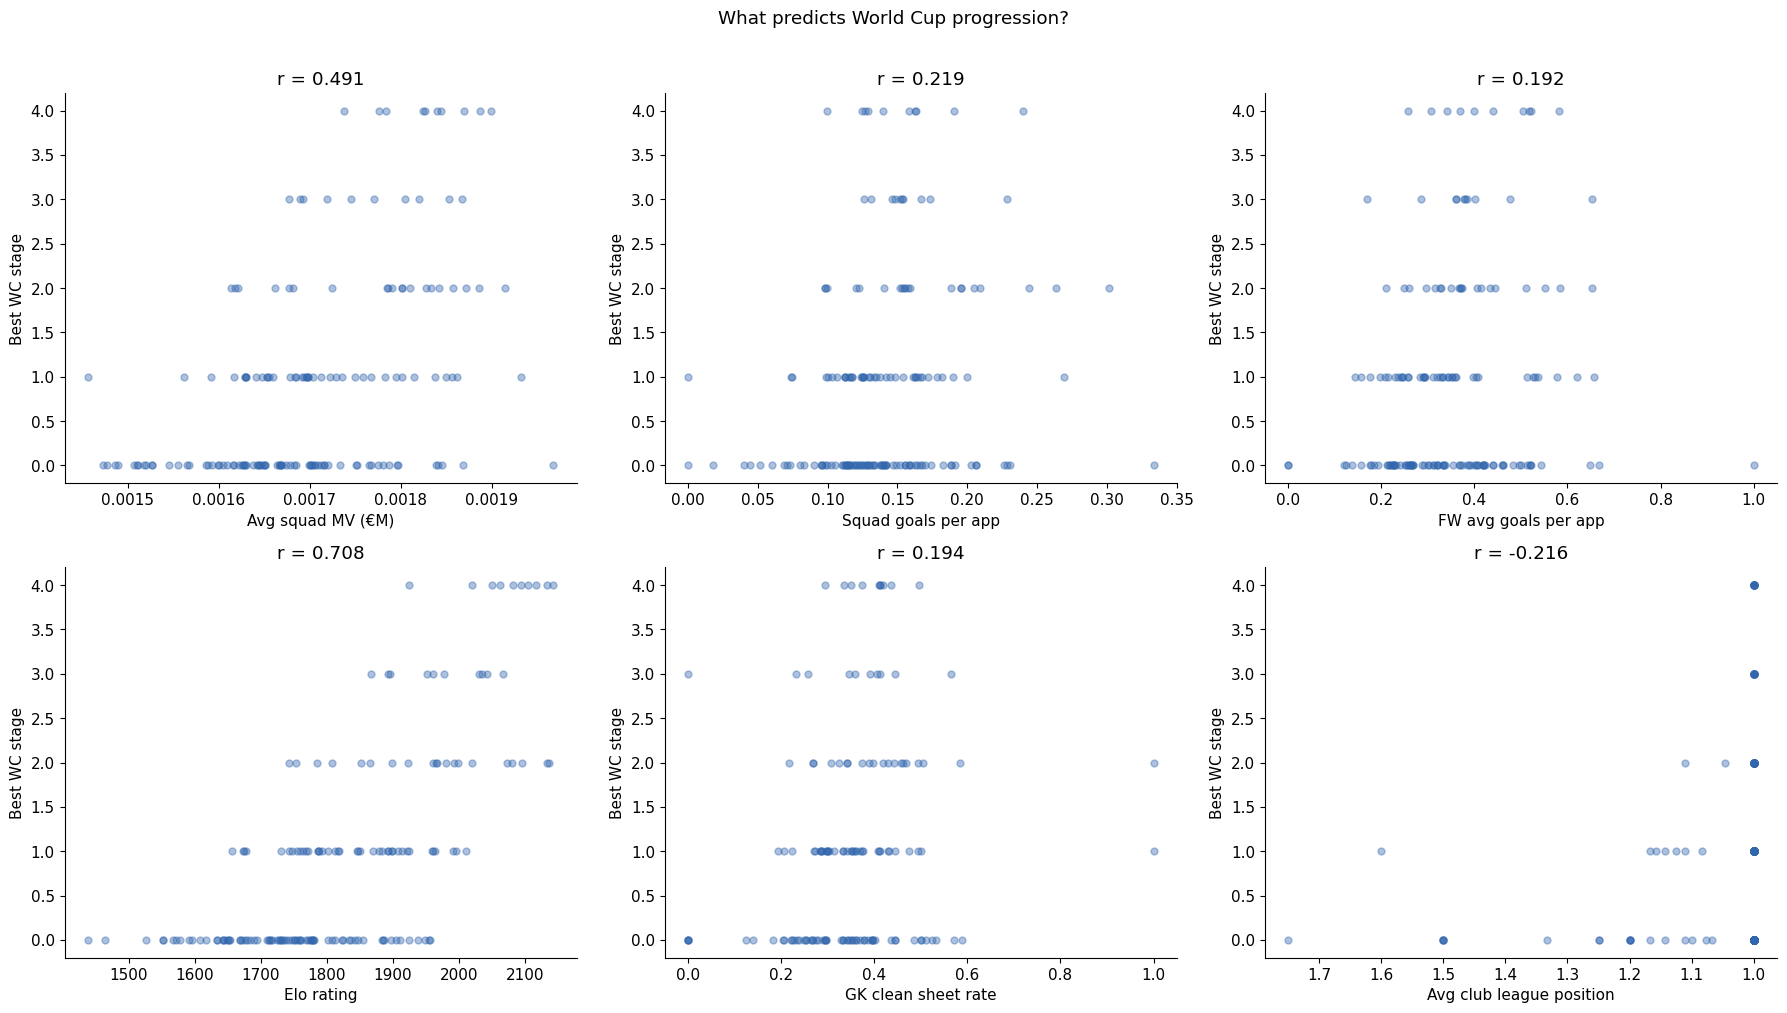

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_configs = [
    ("squad_avg_mv", "Avg squad MV (\u20acM)", 1e6, False),
    ("squad_goals_per_app", "Squad goals per app", 1, False),
    ("FW_avg_goals_per_app", "FW avg goals per app", 1, False),
    ("elo_rating", "Elo rating", 1, False),
    ("GK_avg_clean_sheet_rate", "GK clean sheet rate", 1, False),
    ("squad_avg_club_pos", "Avg club league position", 1, True),
]

for ax, (col, label, divisor, invert) in zip(axes.flat, plot_configs):
    sub = team_df.dropna(subset=[col, "best_stage"])
    ax.scatter(sub[col] / divisor, sub["best_stage"], alpha=0.4, s=25, c="#3266ad")
    corr = sub[[col, "best_stage"]].corr().iloc[0, 1]
    ax.set_xlabel(label)
    ax.set_ylabel("Best WC stage")
    ax.set_title(f"r = {corr:.3f}")
    if invert:
        ax.invert_xaxis()

plt.suptitle("What predicts World Cup progression?", y=1.01)
plt.tight_layout()
plt.show()

**Divergence Cases**

In [26]:
# Standardize to compare: percentile rank within each tournament
for col in ["squad_avg_mv", "elo_rating"]:
    team_df[f"{col}_pctile"] = team_df.groupby("wc_tournament")[col].rank(pct=True)

team_df["divergence"] = team_df["squad_avg_mv_pctile"] - team_df["elo_rating_pctile"]

outliers = team_df.nlargest(10, "divergence")[
    [
        "wc_tournament",
        "national_team",
        "squad_avg_mv",
        "elo_rating",
        "divergence",
        "best_stage",
    ]
]
print("=== Teams where player club strength >> Elo (potential model edge) ===")
print(outliers.to_string(index=False))

outliers_neg = team_df.nsmallest(10, "divergence")[
    [
        "wc_tournament",
        "national_team",
        "squad_avg_mv",
        "elo_rating",
        "divergence",
        "best_stage",
    ]
]
print("\n=== Teams where Elo >> player club strength (potential model miss) ===")
print(outliers_neg.to_string(index=False))

=== Teams where player club strength >> Elo (potential model edge) ===
wc_tournament         national_team  squad_avg_mv  elo_rating  divergence  best_stage
      WC-2010          South Africa   1780.852539        1608    0.649194           0
      WC-2022            Costa Rica   1797.119296        1738    0.581250           0
      WC-2010           Ivory Coast   1767.036724        1716    0.429435           0
      WC-2006 Serbia and Montenegro   1786.884399        1761    0.419355           0
      WC-2006                Mexico   1850.347229        1817    0.354839           1
      WC-2014           South Korea   1668.188935        1633    0.343750           0
      WC-2006                 Spain   1861.838272        1884    0.322581           1
      WC-2018            Costa Rica   1678.327731        1724    0.322581           0
      WC-2018                 Egypt   1645.904818        1617    0.322581           0
      WC-2010                France   1845.062276        1802    0.31

##### **Section 7 - Modeling Summary**

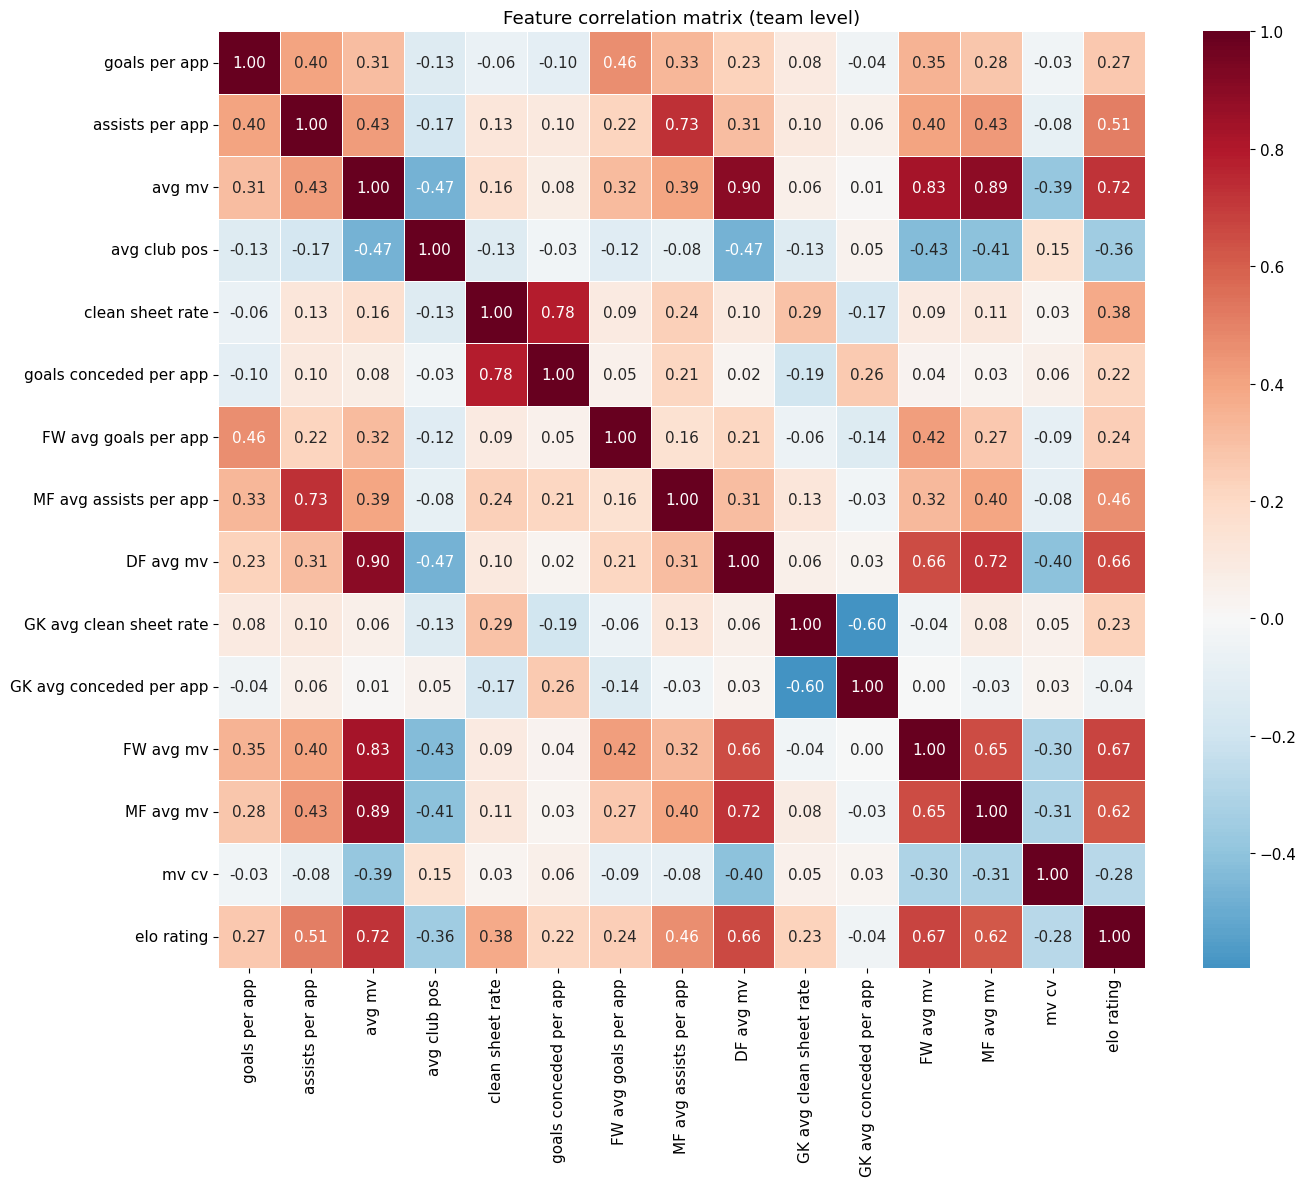

In [27]:
# Full feature correlation matrix
model_features = [
    "squad_goals_per_app",
    "squad_assists_per_app",
    "squad_avg_mv",
    "squad_avg_club_pos",
    "squad_clean_sheet_rate",
    "squad_goals_conceded_per_app",
    "FW_avg_goals_per_app",
    "MF_avg_assists_per_app",
    "DF_avg_mv",
    "GK_avg_clean_sheet_rate",
    "GK_avg_conceded_per_app",
    "FW_avg_mv",
    "MF_avg_mv",
    "squad_mv_cv",
    "elo_rating",
]

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = team_df[model_features].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.5,
    xticklabels=[c.replace("squad_", "").replace("_", " ") for c in model_features],
    yticklabels=[c.replace("squad_", "").replace("_", " ") for c in model_features],
)
ax.set_title("Feature correlation matrix (team level)")
plt.tight_layout()
plt.show()

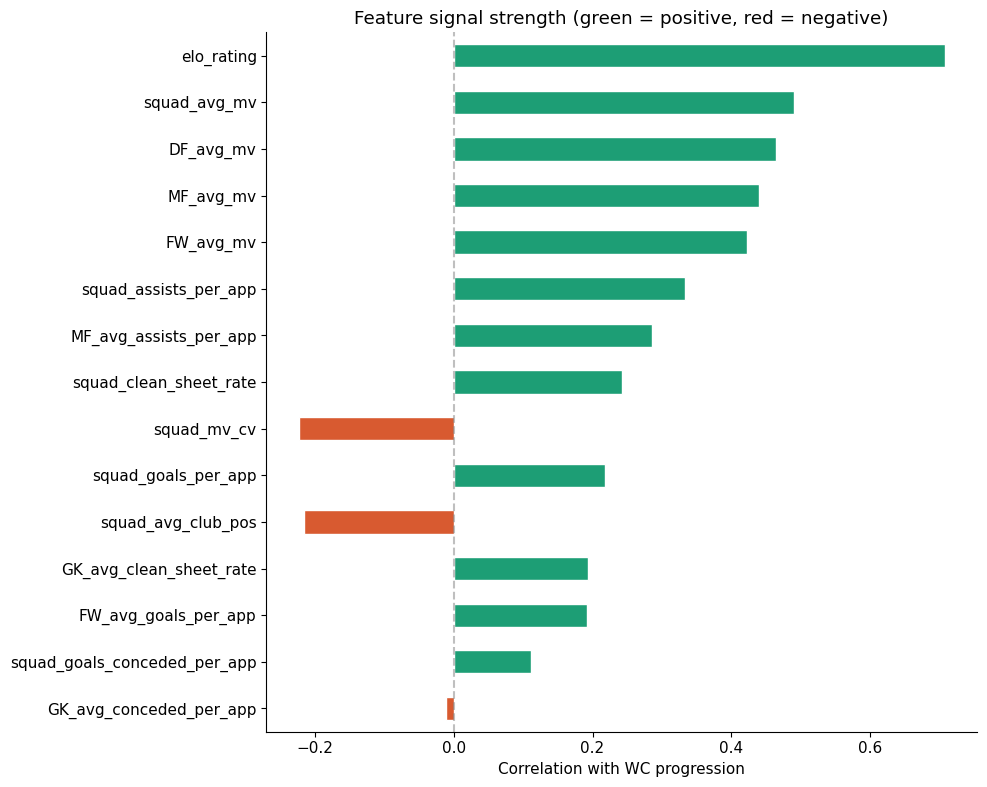

=== Feature signal ranking ===
elo_rating                      0.708
squad_avg_mv                    0.491
DF_avg_mv                       0.465
MF_avg_mv                       0.441
FW_avg_mv                       0.423
squad_assists_per_app           0.333
MF_avg_assists_per_app          0.286
squad_clean_sheet_rate          0.243
squad_mv_cv                    -0.224
squad_goals_per_app             0.219
squad_avg_club_pos             -0.216
GK_avg_clean_sheet_rate         0.194
FW_avg_goals_per_app            0.192
squad_goals_conceded_per_app    0.111
GK_avg_conceded_per_app        -0.011


In [28]:
# Ranked feature importance: correlation with best_stage
feature_signal = (
    team_df[model_features + ["best_stage"]].corr()["best_stage"].drop("best_stage")
)
feature_signal = feature_signal.reindex(
    feature_signal.abs().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1D9E75" if v > 0 else "#D85A30" for v in feature_signal.values]
feature_signal.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_xlabel("Correlation with WC progression")
ax.set_title("Feature signal strength (green = positive, red = negative)")
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("=== Feature signal ranking ===")
print(feature_signal.round(3).to_string())